# Annual GDP Growth and Debt of the 27 EU-Countries

The debt-to-GDP ratio is a metric that compares a country's public debt to its gross domestic product. By comparing what a country owes with what it produces, the debt-to-GDP ratio indicates a particular country's ability to pay back its debts. We want to look at this metric but with an alteration. Instead of looking at debt-to-GDP, we analyze debt-to-GDP-growth.

By comparing debt levels to GDP growth rather than total GDP, we aim to assess how well European countries manage their debt relative to how fast their economies grow. If a country’s debt is increasing but its GDP growth is also robust, it suggests that the economy can sustain higher debt levels without adverse effects. This indicates the effectiveness of fiscal management in stimulating economic growth. If debt increases significantly but GDP growth does not, it might suggest that the debt is not being used effectively to generate economic expansion.

First, we import the relevant packages:

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets # for interactive plots/buttons
from collections import Counter

plt.rcParams.update({"axes.grid":True,"grid.color":"black","grid.alpha":"0.25","grid.linestyle":"--"})
plt.rcParams.update({'font.size': 14})


# importing defined functions from python file 
from dataproject_functions import *

# autoreload modules when code is run. Otherwise, python will not see recent changes. 
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data set

We look at the annual gdp growth and debt of the current 27 EU-countries for the period from 2000 until 2022. 
The data set for the annual gdp growth is from the World Bank and contains the current 27 EU-countries within the period from 2000 to 2022. It can be downloaded here: https://databank.worldbank.org/reports.aspx?source=2&series=NY.GDP.MKTP.KD.ZG&country=#.
The data set for the annual debt comes from Danmarks Statistics (again all 27 countries from 2000 to 2022 are included). It can be downloaded here: 
https://www.statbank.dk/20172. The debt is given in € (Mill. Euro (current prices)).

# Read and clean data

We downloaded both data sets and saved them as xlsx. Therefore, we load the data first.

First the data for the annual gdp growth (in %):

In [148]:
filename_world_bank_update = 'gdp_growth_world_bank_update.xlsx'
# read in data 
gdp_world_bank = pd.read_excel(filename_world_bank_update)
# show first five observations
gdp_world_bank.head(5)

,Series Name,Series Code,Country Name,Country Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
0,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Austria,AUT,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Belgium,BEL,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Greece,GRC,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Italy,ITA,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Lithuania,LTU,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175


Then we load the second data set containing the annual debt:

In [149]:
filename_debt = 'new_debt_data.xlsx'

# removing 2 irrelevant rows and loaading data 
debt = pd.read_excel(filename_debt, skiprows=2)
# show first five observations
debt.head(5)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,2000,2001,2002,2003,2004,2005,2006,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Mill. Euro (current prices),Government EMU-debt,Belgium,280959.5,286055.5,288110.8,285866.7,288418.8,294975.3,297494.9,...,414432.4,431384.3,438504.8,451619.9,454048.4,459388.5,467249.4,515211.9,548456.4,578063.2
1,NaN,NaN,Bulgaria,10177.1,10269.8,8890.3,8126.5,7526.2,6388.6,5721.0,...,7147.6,11619.3,11871.6,14188.1,13182.6,12427.2,12311.1,15131.7,17013.2,19352.9
2,NaN,NaN,Cyprus,6024.5,6660.9,7339.8,8184.8,9055.9,9595.9,9597.7,...,18706.5,19013.8,19296.8,19631.5,18935.6,21343.9,21565.9,25388.1,24744.7,23767.3
3,NaN,NaN,Denmark,93084.0,89464.7,93174.5,89061.4,89394.7,79532.5,71183.3,...,113943.4,117801.4,108532.4,105450.1,105727.0,102597.3,104187.6,131859.7,123539.1,113586.0
4,NaN,NaN,Estonia,315.6,333.4,442.9,489.7,499.9,533.1,628.1,...,1934.2,2129.9,2077.4,2174.1,2174.0,2127.4,2373.4,5094.4,5533.5,6657.4


By looking at the initial data sets we see that both are in wide data format. 
For both data sets we need to do some data cleaning. 
For example, we saw that the column headers have two rows in the GDP data set. However, we would like to delete the second row such that there is only one row for the header. There are also some unnecessary columns in the current gdp data set (for example Series Code or Country Code). These will be deleted. 

In [150]:
# data cleaning for the first data set
# delete irrelevant columns
del gdp_world_bank["Series Code"]
del gdp_world_bank["Country Code"]



# Removing the part in brackets
gdp_world_bank.columns = [name.split(' [')[0] for name in gdp_world_bank.columns]


## rename variables 
gdp_world_bank.rename(columns = {'Series Name':'Variable'}, inplace=True)
gdp_world_bank.rename(columns = {'Country Name':'Countries'}, inplace=True)



For the debt data set, we do similar data cleaning: We remove the first two columns and rename the column containing the 27 countries. Especially for merging the two data sets, it might be a bit easier to name columns consistently. Additionally, we want to have the same notation for the countries in both data sets. This is also necessary for merging the data sets later.

In [151]:
# removing 2 columns
debt = debt.iloc[:, 2:]

# renaming
debt.rename(columns = {'Unnamed: 2':'Countries'}, inplace=True)

# Renaming countries to match debt dataset with gdp dataset later
country_renames = {
    'Slovakia': 'Slovak Republic',
    'Czech Republic': 'Czechia'
}
debt['Countries'] = debt['Countries'].replace(country_renames)

The cleaned data sets look like these: 

In [152]:
gdp_world_bank.head(5)

,Variable,Countries,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,GDP growth (annual %),Austria,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,3.454042,3.727415,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),Belgium,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,2.552350,3.676881,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),Greece,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,5.652434,3.273747,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),Italy,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,1.790640,1.487073,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),Lithuania,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,7.414121,11.107480,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175


In [153]:
debt.head(5)

,Countries,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Belgium,280959.5,286055.5,288110.8,285866.7,288418.8,294975.3,297494.9,300063.7,327683.2,...,414432.4,431384.3,438504.8,451619.9,454048.4,459388.5,467249.4,515211.9,548456.4,578063.2
1,Bulgaria,10177.1,10269.8,8890.3,8126.5,7526.2,6388.6,5721.0,5296.9,4848.6,...,7147.6,11619.3,11871.6,14188.1,13182.6,12427.2,12311.1,15131.7,17013.2,19352.9
2,Cyprus,6024.5,6660.9,7339.8,8184.8,9055.9,9595.9,9597.7,9461.9,8658.6,...,18706.5,19013.8,19296.8,19631.5,18935.6,21343.9,21565.9,25388.1,24744.7,23767.3
3,Denmark,93084.0,89464.7,93174.5,89061.4,89394.7,79532.5,71183.3,63755.0,80547.5,...,113943.4,117801.4,108532.4,105450.1,105727.0,102597.3,104187.6,131859.7,123539.1,113586.0
4,Estonia,315.6,333.4,442.9,489.7,499.9,533.1,628.1,617.5,749.4,...,1934.2,2129.9,2077.4,2174.1,2174.0,2127.4,2373.4,5094.4,5533.5,6657.4


Now we change the data format from wide to long. Especially for the later merge of both data frames, it makes more sense to have the data sets in long format.

In [154]:
# from wide to long
gdp_growth_long = pd.melt(gdp_world_bank, id_vars=['Countries'], value_vars = ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
                                                                                '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020','2021','2022'],
var_name='year', value_name='annual_gdp_growth')
# show first five observations
gdp_growth_long.head(5)

,Countries,year,annual_gdp_growth
0,Austria,2000,3.375722
1,Belgium,2000,3.716679
2,Greece,2000,3.919771
3,Italy,2000,3.786955
4,Lithuania,2000,3.695525


In [155]:
# wide to long
debt_long = pd.melt(debt, id_vars=['Countries'], var_name='year', value_name='debt')
# show first five observations
debt_long.head(5)


,Countries,year,debt
0,Belgium,2000,280959.5
1,Bulgaria,2000,10177.1
2,Cyprus,2000,6024.5
3,Denmark,2000,93084.0
4,Estonia,2000,315.6


# Exploring data sets

We explore the summary statistics of both data sets now. Since we have both data formats, we are also able to look at a summary across countries to compare different years in the wide format. This can be helpful to identify outlier-years.

In [156]:
# summary statistic of gdp growth for the wide format: 
# get a summary statistic for the wide format for each year across different countries 
description_gdp_wide = gdp_world_bank.describe()
description_gdp_wide


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,...,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,5.130061,3.045232,3.197920,3.209616,4.373774,4.004903,5.180710,5.136779,1.347001,-5.352893,...,0.286484,2.205493,3.653492,2.580062,3.962905,3.383565,2.965571,-4.354673,7.215687,3.855848
std,3.467922,1.834668,2.255573,2.791392,2.281927,2.656944,2.465906,2.831966,3.109683,3.972067,...,2.177185,2.273906,4.593814,1.265638,2.383059,2.009536,1.655607,3.639918,2.884774,2.193676
min,1.166527,-1.174697,-0.197974,-0.930521,0.140269,0.599142,1.625034,0.277373,-5.132001,-14.838608,...,-6.553078,-1.829309,-0.196088,-0.487173,1.092149,0.925811,0.483198,-11.167298,2.838180,-1.287411
25%,3.706102,1.812570,1.610705,0.989727,2.782437,2.282901,3.638715,3.356484,-0.317674,-6.145852,...,-0.722224,0.870819,1.822533,2.004461,2.624078,1.907544,1.861231,-7.086725,5.942231,2.447467
50%,4.001029,3.074355,2.730948,2.960260,4.336856,3.506835,4.713829,5.075022,0.959879,-4.657331,...,0.437591,1.902173,2.342591,2.518828,3.192410,2.820323,2.682760,-3.886084,6.844522,3.724549
75%,5.460843,4.013324,5.222139,4.655702,5.169937,5.296393,6.449035,7.020848,3.098127,-3.293048,...,1.181195,2.889763,3.861889,3.096669,4.977699,4.242378,3.944176,-2.389739,8.120981,5.159247
max,19.681269,6.526109,7.088129,10.565957,10.428113,10.720366,11.971836,11.107480,9.307467,2.832184,...,5.473356,8.828999,24.475253,6.454554,10.869269,8.470295,7.058727,6.617195,15.125220,9.433022


In [157]:
## get a summary statistic for the debt data frame 
descripton_debt_wide = debt.describe()
descripton_debt_wide

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
count,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,...,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01
mean,1.935240e+05,2.002349e+05,2.070149e+05,2.165488e+05,2.275294e+05,2.377860e+05,2.434668e+05,2.477750e+05,2.669535e+05,2.971351e+05,...,3.788675e+05,3.883111e+05,3.936111e+05,4.004164e+05,4.050799e+05,4.086630e+05,4.120407e+05,4.573346e+05,4.821909e+05,4.998471e+05
std,3.672209e+05,3.780732e+05,3.898513e+05,4.105146e+05,4.298885e+05,4.503465e+05,4.634989e+05,4.712226e+05,4.957783e+05,5.408636e+05,...,6.582775e+05,6.729476e+05,6.804660e+05,6.932865e+05,7.027566e+05,7.106377e+05,7.196171e+05,7.925658e+05,8.375858e+05,8.674273e+05
min,3.156000e+02,3.334000e+02,4.429000e+02,4.897000e+02,4.999000e+02,5.331000e+02,6.281000e+02,6.175000e+02,7.494000e+02,1.023100e+03,...,1.934200e+03,2.129900e+03,2.077400e+03,2.174100e+03,2.174000e+03,2.127400e+03,2.373400e+03,5.094400e+03,5.533500e+03,6.657400e+03
25%,6.778650e+03,8.161100e+03,8.115050e+03,8.155650e+03,8.291050e+03,8.643000e+03,8.899600e+03,8.737750e+03,8.460550e+03,1.132825e+04,...,2.211330e+04,2.461685e+04,2.569210e+04,2.569375e+04,2.541430e+04,2.679510e+04,2.665915e+04,3.140620e+04,3.181160e+04,3.345700e+04
50%,3.949400e+04,4.096920e+04,4.198740e+04,4.340930e+04,5.050510e+04,5.407560e+04,6.229880e+04,6.375500e+04,7.331730e+04,8.020000e+04,...,1.139434e+05,1.178014e+05,1.085324e+05,1.054501e+05,1.057270e+05,1.025973e+05,1.041876e+05,1.318597e+05,1.235391e+05,1.344690e+05
75%,1.447312e+05,1.550626e+05,1.613530e+05,1.670990e+05,1.786337e+05,1.941898e+05,2.030000e+05,2.122948e+05,2.332925e+05,2.655383e+05,...,2.918638e+05,2.998150e+05,3.019968e+05,3.056282e+05,3.037162e+05,3.100714e+05,3.058422e+05,3.287845e+05,3.440660e+05,3.536477e+05
max,1.353569e+06,1.420027e+06,1.436142e+06,1.471326e+06,1.526400e+06,1.591581e+06,1.657334e+06,1.677650e+06,1.738647e+06,1.839233e+06,...,2.201918e+06,2.203743e+06,2.239410e+06,2.285705e+06,2.329932e+06,2.381640e+06,2.410323e+06,2.657352e+06,2.823692e+06,2.949331e+06


The tables offer mean, standard deviation and quantiles of the respective variables for each year. 
We can see in the tables that the mean GDP growth has a high fluctuation in the past two decades. However, the mean debt seems to have an upward trend. 

We can also visualize parts of the summary statistics like the standard deviation.

We plot the time series of the dispersion of annual GDP growth and debt: 

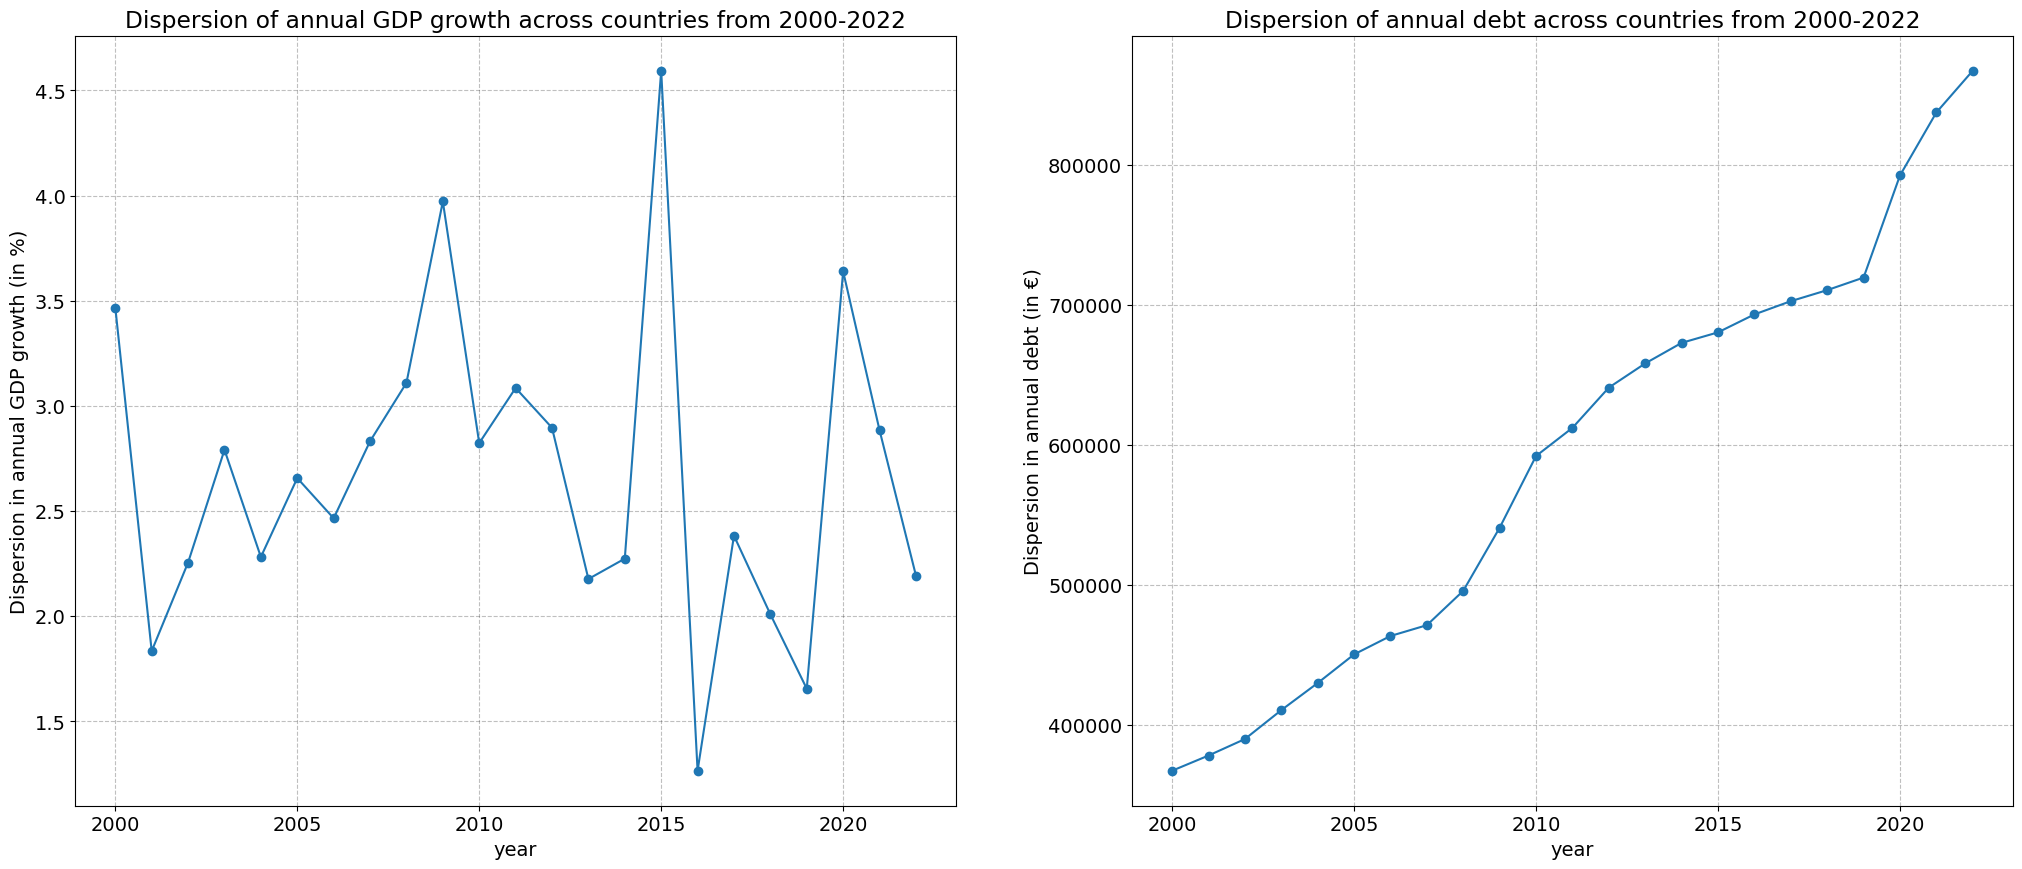

In [173]:
fig = plt.figure(frameon=True,figsize=(25,10), dpi=100)
# first plot 
ax = fig.add_subplot(1,2,1)

# plot dispersion of gdp growth across countries
description_gdp_wide.loc["std"].plot(ax=ax,style='-o')
# set labels and title 
ax.set_xlabel('year')
ax.set_ylabel('Dispersion in annual GDP growth (in %)')
ax.set_title('Dispersion of annual GDP growth across countries from 2000-2022')


# second plot
az = fig.add_subplot(1,2,2)
# plotting yearly dispersion of debt across countries
descripton_debt_wide.loc["std"].plot(ax=az,style='-o')
# set labels and title 
az.set_xlabel('year')
az.set_ylabel('Dispersion in annual debt (in €)')
az.set_title('Dispersion of annual debt across countries from 2000-2022')
plt.show();


The two time series behave differently as already noticed in the previous tables. In general, there is a trend in the dispersion of annual debt across countries, this suggests a high variability in debt across countries. With some countries increasing their debt significantly more than others. Whereas, the GDP growth fluctuates more, this could be due to many different factors that have an effect on economies. Most notably market crashes and booms.

## Interactive Time Series

Using the data sets in long format, we can create interactive plots to look at the annual GDP growth and debt of each country over time: 

In [159]:
# Define the list of countries for which we want to have a drop down 
countries = list(gdp_world_bank['Countries'])

In [160]:
# Create the dropdown widget
# the function interactive_figure is defined in dataproject_functions.pj
widgets.interact(interactive_figure, data1 = widgets.fixed(gdp_growth_long), data2 = widgets.fixed(debt_long),
                  country=countries);

interactive(children=(Dropdown(description='country', options=('Austria', 'Belgium', 'Greece', 'Italy', 'Lithu…

We see that in general the GDP growth is fluctuating for most of the countries over the years. Whereas the time series of debt has an upward trend for most of the countries. This is in line with the previous summary statistics across countries for each year.

## More summary statistics for the long format

We can also add summmary statistics for the data in long format. We don't go into detail here. However, if you are interested in exploring the differences in countries in each year, then the long format is suitable. Then, you can just print them by removing the "#".

In [161]:
# Sorting the countries together
gdp_growth_long_sort = gdp_growth_long.sort_values(['Countries','year'])


# First calculate mean gdp growth per country over all years
gdp_growth_mean = gdp_growth_long_sort.groupby('Countries')['annual_gdp_growth'].mean().rename('country_mean_gdp_growth')

# Joining the mean gdp growth back to the original dataframe
gdp_growth_long = gdp_growth_long_sort.join(gdp_growth_mean, on='Countries')

# Calculating the deviation from each country's mean gdp growth
gdp_growth_long['gdp_mean_dev'] = gdp_growth_long['annual_gdp_growth'] - gdp_growth_long['country_mean_gdp_growth']

#gdp_growth_long.head(30)

In [162]:
# Sorting the countries together
debt_long_sort = debt_long.sort_values(['Countries','year'])


# First calculate mean debt per country over all years
debt_mean = debt_long_sort.groupby('Countries')['debt'].mean().rename('country_mean_debt')

# Joining the mean debt back to the original dataframe
debt_long = debt_long_sort.join(debt_mean, on='Countries')

# Calculating the deviation from each country's mean debt
debt_long['debt_mean_dev'] = debt_long['debt'] - debt_long['country_mean_debt']

#debt_long.head(30)

Another idea would be to look which country had the highest/lowest GDP growth or debt for each year. We defined a function in 'dataproject_functions.pj' which does this for us.

We start by exploring the annual GDP growth: 

In [163]:
# apply function to get countries with lowest/highest GDP growth per year
countries_with_extreme_gdp_growth_per_year, min_gdp_growth_counter, max_gdp_growth_counter = find_country_with_extreme_value_per_year(gdp_growth_long, 'annual_gdp_growth')


#countries_with_extreme_gdp_growth_per_year

In [164]:
print("\nOccurrences of each country as the country with the lowest annual GDP growth:")
print(min_gdp_growth_counter)

print("\nOccurrences of each country as the country with the highest annual GDP growth:")
print(max_gdp_growth_counter)


Occurrences of each country as the country with the lowest annual GDP growth:
Counter({'Greece': 7, 'Malta': 2, 'Portugal': 2, 'Estonia': 2, 'Cyprus': 2, 'Italy': 2, 'Slovak Republic': 1, 'Germany': 1, 'Hungary': 1, 'Lithuania': 1, 'Spain': 1, 'Finland': 1})

Occurrences of each country as the country with the highest annual GDP growth:
Counter({'Ireland': 6, 'Malta': 4, 'Latvia': 4, 'Lithuania': 3, 'Romania': 2, 'Poland': 1, 'Slovak Republic': 1, 'Estonia': 1, 'Cyprus': 1})


It is rather less suprising that Greece, as a country suffering from a debt crisis after 2008 and a large recession, had seven times the lowest annual GDP growth for all EU-member countries.

Surprisingly, Ireland is the country having the highest GDP growth in the past two decades.


Now we do the same for the annual debt:

In [165]:
# apply function to get countries with lowest/highest debt per year
countries_with_extreme_debt_per_year, min_debt_counter, max_debt_counter = find_country_with_extreme_value_per_year(debt_long, 'debt')
print(countries_with_extreme_debt_per_year)

    year Countries_min  debt_min Countries_max   debt_max
0   2000       Estonia     315.6         Italy  1353569.3
1   2001       Estonia     333.4         Italy  1420026.6
2   2002       Estonia     442.9         Italy  1436141.8
3   2003       Estonia     489.7         Italy  1471325.7
4   2004       Estonia     499.9         Italy  1526400.5
5   2005       Estonia     533.1         Italy  1591580.6
6   2006       Estonia     628.1         Italy  1657334.2
7   2007       Estonia     617.5         Italy  1677649.8
8   2008       Estonia     749.4         Italy  1738647.0
9   2009       Estonia    1023.1         Italy  1839232.6
10  2010       Estonia     981.9       Germany  2102672.3
11  2011       Estonia    1027.4       Germany  2139149.2
12  2012       Estonia    1762.5       Germany  2216704.5
13  2013       Estonia    1934.2       Germany  2201917.7
14  2014       Estonia    2129.9       Germany  2203742.6
15  2015       Estonia    2077.4         Italy  2239409.8
16  2016      

In [166]:
print("\nOccurrences of each country as the country with the lowest debt:")
print(min_debt_counter)
print("\nOccurrences of each country as the country with the highest debt:")
print(max_debt_counter)


Occurrences of each country as the country with the lowest debt:
Counter({'Estonia': 23})

Occurrences of each country as the country with the highest debt:
Counter({'Italy': 15, 'Germany': 5, 'France': 3})


Compared to the annual GDP growth, Italy is the country which had most often the highest debt. Greece is not even once listed. For the lowest debt, Estonia incurs the lowest debts in each of the past years since 2000. Estonia is a rather small country in the EU, but it is still interesting to find out that it made the lowest debts in the whole EU for more than two decades.

# Merge data sets

We will join the two data sets by country and year. For the merge we use the data sets in long format.


In [167]:
# merge using specific Countries and year 
gdp_debt_merge = pd.merge(gdp_growth_long, debt_long, on=['Countries','year'], how='left')


# Calculate the ratio of average GDP growth to average debt
gdp_debt_merge['gdp_to_debt_ratio'] = gdp_debt_merge['country_mean_gdp_growth'] / gdp_debt_merge['country_mean_debt']

gdp_debt_merge.head()


,Countries,year,annual_gdp_growth,country_mean_gdp_growth,gdp_mean_dev,debt,country_mean_debt,debt_mean_dev,gdp_to_debt_ratio
0,Austria,2000,3.375722,1.511706,1.864016,141245.5,237894.756522,-96649.256522,0.000006
1,Austria,2001,1.267168,1.511706,-0.244538,147154.2,237894.756522,-90740.556522,0.000006
2,Austria,2002,1.651554,1.511706,0.139847,151295.9,237894.756522,-86598.856522,0.000006
3,Austria,2003,0.941471,1.511706,-0.570236,152688.1,237894.756522,-85206.656522,0.000006
4,Austria,2004,2.735120,1.511706,1.223414,157985.4,237894.756522,-79909.356522,0.000006


After, the merge we want to do a bar plot to look at the ratio of average GDP and average debt for each of the 27 countries.

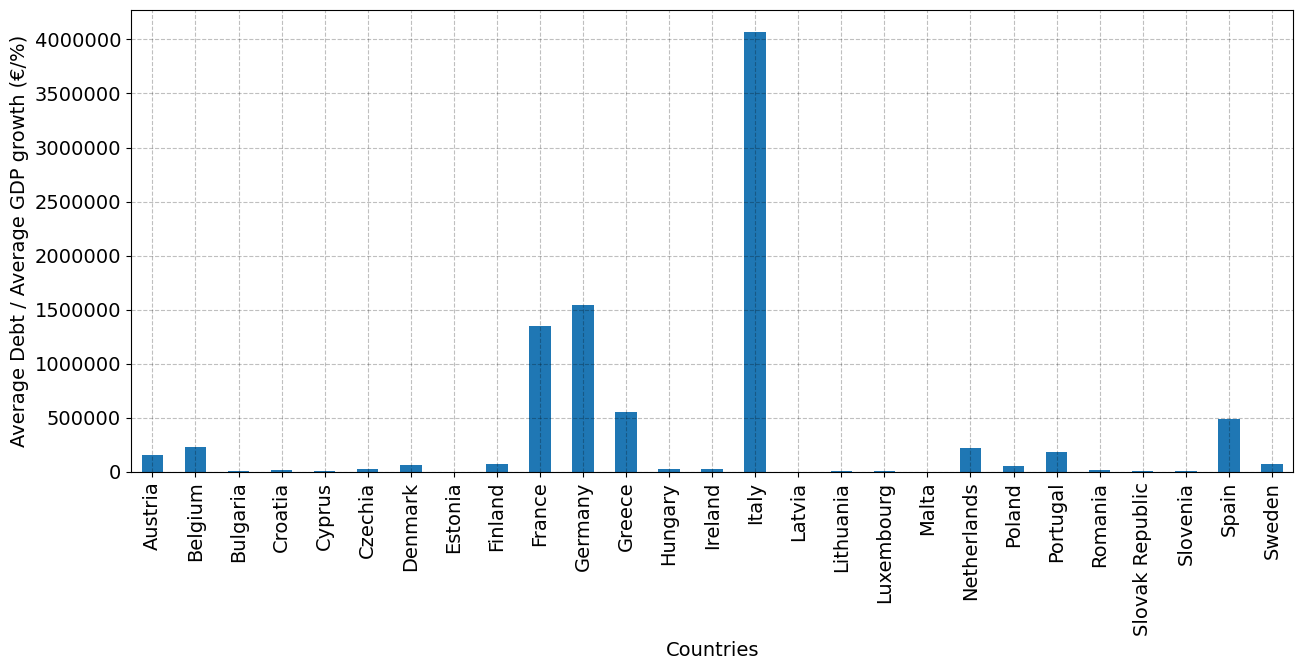

In [172]:
# calculating the ratio 
average_debt = debt_long.groupby('Countries')['debt'].mean()
average_gdp_growth = gdp_growth_long.groupby('Countries')['annual_gdp_growth'].mean()

ratio = average_debt / average_gdp_growth 

# plotting 
plt.figure(figsize=(15, 6))
plt.ticklabel_format(scilimits=(-5, 8))
# bar plot 
ax = ratio.plot.bar()
# labeling y-axes 
ax.set_ylabel('Average Debt / Average GDP growth (€/%)');


Estonia is the country with the lowest ratio of average debt and average GDP growth. This results directly from the fact that the country makes the lowest debts in the whole EU. Whereas Italy making the highest debts in the past 20 years, has also the highest ratio.

 Then we do a scatter plot where each point represents the average GDP growth and average debt for each seperate country. To highlight different countries, we try to use distinct colors.

/var/folders/lp/437mv5sn2m10gm5j1vk_4d200000gn/T/ipykernel_2909/3165193868.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap(colormap_name, colors_per_colormap)


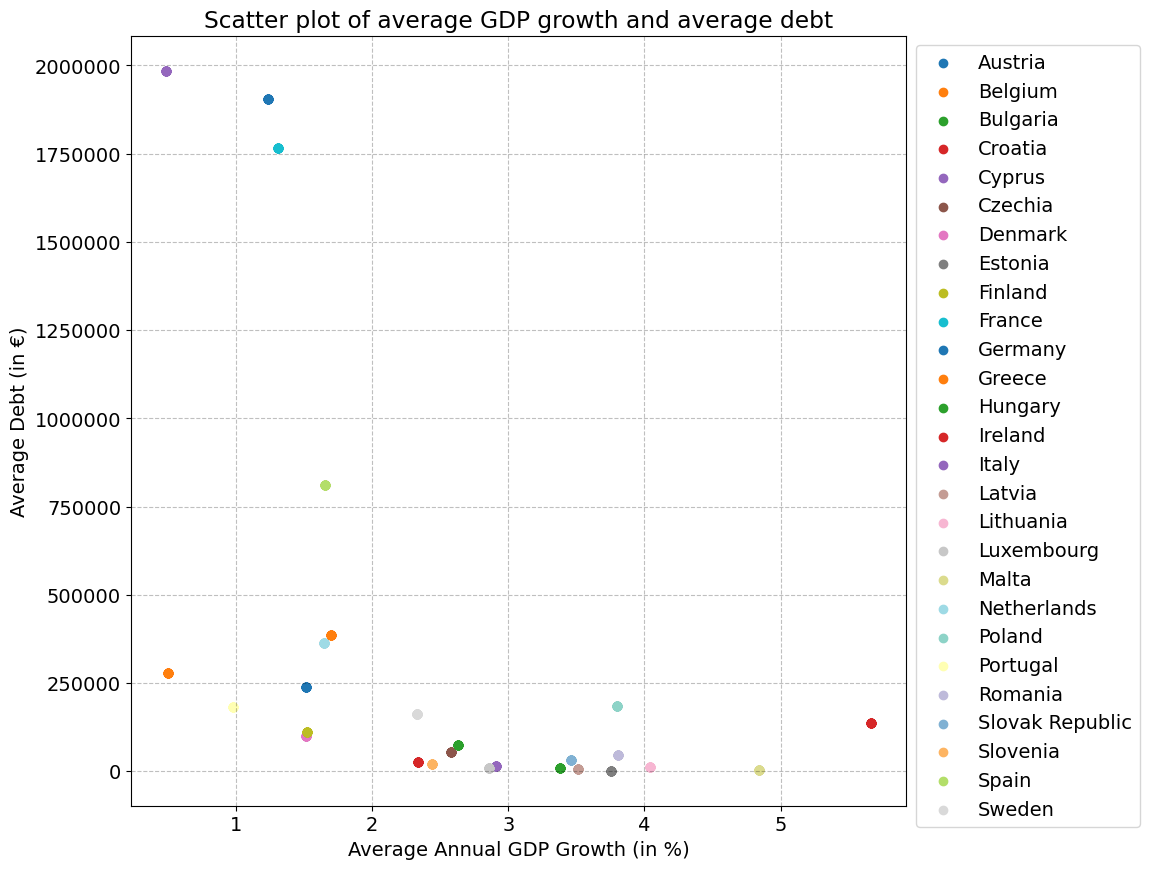

In [171]:
# Determine the number of unique countries
num_countries = len(gdp_debt_merge['Countries'].unique())

# Choose colormaps with distinct colors
colormap_names = ['tab10', 'tab20', 'Set3']
colors_per_colormap = num_countries // len(colormap_names) + 1

# Concatenate multiple colormaps to get more unique colors
colors = []
for colormap_name in colormap_names:
    colormap = plt.cm.get_cmap(colormap_name, colors_per_colormap)
    for i in range(colors_per_colormap):
        colors.append(colormap(i))

# Create a scatter plot
fig = plt.figure(frameon=True, figsize=(10, 10), dpi=100)
ax_A = fig.add_subplot(1, 1, 1)

# Set labels
ax_A.set_xlabel("Average Annual GDP Growth (in %)")
ax_A.set_ylabel("Average Debt (in €)")
ax_A.set_title('Scatter plot of average GDP growth and average debt')

# Iterate over each country's data and plot them separately with different colors
for i, (country, data) in enumerate(gdp_debt_merge.groupby('Countries')):
    ax_A.scatter(data['country_mean_gdp_growth'], data['country_mean_debt'], label=country, color=colors[i])

# Add legend
ax_A.legend(bbox_to_anchor=(1, 1))

# Show the plot
plt.ticklabel_format(scilimits=(-5, 8))
plt.show();

Countries that mark an outlier here are again Italy and Ireland. But also Germany and France, which where the countries making one of the highest debts. However, one must also note that Italy, Germany and France are the largest economies in the whole EU. That might explain why these countries have rather high debts. 

# Conclusion

From the time series graphs, we see that debt is generally trending upwards, while the GDP-growth is more volatile.
In the debt-to-GDP-ratio graph, the biggest economies within the EU, France, Germany, and Italy have the highest ratios. Oppositely, the smallest economies, the Baltic countries, and Malta have the lowest ratios. Big economies are able to employ more expansive fiscal policies and leverage debt, while the small economies have to employ conservative fiscal policies.

In the last scatter plot, Ireland has the highest average GDP-growth of all countries, while maintaining a relatively low debt level, being only slightly higher than Denmark and Finland, in average debt. It is worth noting that Ireland has the second lowest corporate tax in Europe, being a hub for the biggest international companies in Europe boosts their GDP-growth.

Greece and Italy have the lowest average GDP-growth of all countries. Greece has relatively low level of debt, being below Belgium, The Netherlands, and slightly above Austria. Because of Greece's debt crisis during the 2008 recession, they are more cautious to take on additional debt.

Overall, our analysis helped to get some insights into the different fiscal approaches employed by the European countries.